# Stop Level Analysis
Purpose: analyze, clean, and preprocess 'Stop_level.csv'

In [146]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read input data
INPUT_FOLDER = '../datasets/raw/'
FILE = 'Stop_level.csv'

stop_df = pd.read_csv(INPUT_FOLDER + FILE)
stop_df

/var/folders/pv/85_vb9dj4gjf69d94b0q3ty00000gn/T/ipykernel_7219/1158246558.py:5: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_df = pd.read_csv(INPUT_FOLDER + FILE)


,OPERATION_DATE,STOP_ID,STOP_NM,SERVICE_RTE_LIST,SCHED_DAY_TYPE_CODED_NUM,DAY_CODE,TRIPS_COUNT,TOTAL_BOARDINGS,TOTAL_ALIGHTINGS,AVG_DEPARTURE_LOAD
0,2025-01-02,25,BLANCHARD ST & 1ST AVE,678,0,WK,2,0,0,0
1,2025-01-02,100,1ST AVE & SPRING ST,677,0,WK,328,315,252,1
2,2025-01-02,101,SPRING ST & 3RD AVE,677,0,WK,163,611,105,5
3,2025-01-02,102,SPRING ST & 4TH AVE,2,0,WK,70,62,46,5
4,2025-01-02,102,SPRING ST & 4TH AVE,677,0,WK,163,412,35,8
...,...,...,...,...,...,...,...,...,...,...
2968570,2026-01-01,99756,JUANITA WOODINVILLE WAY NE & NE 163RD PL,231,20260101,NaN,14,0,0,2
2968571,2026-01-01,99760,BRICKYARD RD NE & NE 170TH PL,231,20260101,NaN,14,0,2,2
2968572,2026-01-01,99760,BRICKYARD RD NE & NE 170TH PL,239,20260101,NaN,32,5,2,2
2968573,2026-01-01,99811,HIGHLANDS DR NE,203,20260101,NaN,44,2,1,0


## Data Inspection

In [148]:
print("\nColumn Names and Types:")
stop_df.info()


Column Names and Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968575 entries, 0 to 2968574
Data columns (total 10 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   OPERATION_DATE            object
 1   STOP_ID                   int64 
 2   STOP_NM                   object
 3   SERVICE_RTE_LIST          int64 
 4   SCHED_DAY_TYPE_CODED_NUM  int64 
 5   DAY_CODE                  object
 6   TRIPS_COUNT               int64 
 7   TOTAL_BOARDINGS           int64 
 8   TOTAL_ALIGHTINGS          int64 
 9   AVG_DEPARTURE_LOAD        int64 
dtypes: int64(7), object(3)
memory usage: 226.5+ MB


In [149]:
print("\nBasic Statistics:")
stop_df.describe().T


Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
STOP_ID,2968575.0,4.435469e+04,2.798024e+04,25.0,18145.0,47270.0,69610.0,99830.0
SERVICE_RTE_LIST,2968575.0,1.888212e+02,1.867422e+02,1.0,50.0,150.0,245.0,989.0
SCHED_DAY_TYPE_CODED_NUM,2968575.0,2.624777e+06,6.801897e+06,0.0,0.0,0.0,1.0,20260101.0
TRIPS_COUNT,2968575.0,4.674196e+01,3.375946e+01,1.0,23.0,40.0,66.0,366.0
TOTAL_BOARDINGS,2968575.0,3.253516e+01,8.203731e+01,0.0,1.0,6.0,25.0,2012.0
TOTAL_ALIGHTINGS,2968575.0,3.253598e+01,8.161581e+01,0.0,1.0,6.0,26.0,2350.0
AVG_DEPARTURE_LOAD,2968575.0,5.600972e+00,5.879958e+00,0.0,2.0,4.0,8.0,172.0


### Data Type Conversion

In [150]:
stop_clean = stop_df.copy()

# Convert date column to datetime
stop_clean['OPERATION_DATE'] = pd.to_datetime(stop_clean['OPERATION_DATE'])

# Convert categorical columns to category type
stop_clean['DAY_CODE'] = stop_clean['DAY_CODE'].astype('category')

print("\nData types after conversion:")
print(stop_clean.dtypes)


Data types after conversion:
OPERATION_DATE              datetime64[ns]
STOP_ID                              int64
STOP_NM                             object
SERVICE_RTE_LIST                     int64
SCHED_DAY_TYPE_CODED_NUM             int64
DAY_CODE                          category
TRIPS_COUNT                          int64
TOTAL_BOARDINGS                      int64
TOTAL_ALIGHTINGS                     int64
AVG_DEPARTURE_LOAD                   int64
dtype: object


### Missing Data

In [151]:
stop_df.isna().sum()

OPERATION_DATE                   0
STOP_ID                          0
STOP_NM                          0
SERVICE_RTE_LIST                 0
SCHED_DAY_TYPE_CODED_NUM         0
DAY_CODE                    384757
TRIPS_COUNT                      0
TOTAL_BOARDINGS                  0
TOTAL_ALIGHTINGS                 0
AVG_DEPARTURE_LOAD               0
dtype: int64

In [152]:
# Investigate NaN values in DAY_CODE
stop_df[stop_df['DAY_CODE'].isna()]

,OPERATION_DATE,STOP_ID,STOP_NM,SERVICE_RTE_LIST,SCHED_DAY_TYPE_CODED_NUM,DAY_CODE,TRIPS_COUNT,TOTAL_BOARDINGS,TOTAL_ALIGHTINGS,AVG_DEPARTURE_LOAD
2583818,2025-11-15,100,1ST AVE & SPRING ST,677,20251115,NaN,166,408,339,3
2583819,2025-11-15,101,SPRING ST & 3RD AVE,677,20251115,NaN,166,674,98,7
2583820,2025-11-15,102,SPRING ST & 4TH AVE,2,20251115,NaN,68,0,0,0
2583821,2025-11-15,102,SPRING ST & 4TH AVE,677,20251115,NaN,166,362,83,9
2583822,2025-11-15,103,SPRING ST & 8TH AVE,677,20251115,NaN,166,199,221,8
...,...,...,...,...,...,...,...,...,...,...
2968570,2026-01-01,99756,JUANITA WOODINVILLE WAY NE & NE 163RD PL,231,20260101,NaN,14,0,0,2
2968571,2026-01-01,99760,BRICKYARD RD NE & NE 170TH PL,231,20260101,NaN,14,0,2,2
2968572,2026-01-01,99760,BRICKYARD RD NE & NE 170TH PL,239,20260101,NaN,32,5,2,2
2968573,2026-01-01,99811,HIGHLANDS DR NE,203,20260101,NaN,44,2,1,0


In [153]:
# Observation: DAY_CODE column has NaN values because SCHED_DAY_TYPE_CODED_NUM contains actual date values instead of the expected day type codes

# Extract the actual day of week from OPERATION_DATE
stop_clean['DAY_OF_WEEK'] = stop_clean['OPERATION_DATE'].dt.dayofweek

# Map day of week to DAY_CODE labels
def map_day_type(day_of_week):
    if day_of_week == 6:  # Sunday
        return 2
    elif day_of_week == 5:  # Saturday
        return 1
    else:  # Monday-Friday
        return 0

stop_clean['SCHED_DAY_TYPE_CODED_NUM'] = stop_clean['DAY_OF_WEEK'].apply(map_day_type)

stop_clean['DAY_CODE'] = stop_clean['SCHED_DAY_TYPE_CODED_NUM'].map({0: 'WK', 1: 'SA', 2: 'SU'})

print(f"\nNaN values in DAY_CODE: {stop_clean['DAY_CODE'].isna().sum()}")


NaN values in DAY_CODE: 0


In [154]:
# Validate cleaned datasets
print(f"\nRemaining missing values:")
print(stop_clean.isnull().sum())


Remaining missing values:
OPERATION_DATE              0
STOP_ID                     0
STOP_NM                     0
SERVICE_RTE_LIST            0
SCHED_DAY_TYPE_CODED_NUM    0
DAY_CODE                    0
TRIPS_COUNT                 0
TOTAL_BOARDINGS             0
TOTAL_ALIGHTINGS            0
AVG_DEPARTURE_LOAD          0
DAY_OF_WEEK                 0
dtype: int64


### Data Validation

In [155]:
# Check for duplicates
duplicates = stop_clean.duplicated().sum()
print("Duplicated rows: ", duplicates)

Duplicated rows:  0


In [156]:
# Check for duplicates based on key columns
dup_values = stop_clean.duplicated(subset=['OPERATION_DATE', 'STOP_ID', 'SERVICE_RTE_LIST'], keep=False)
print(f"Duplicate stop-route-date combinations: {dup_values.sum()}")

Duplicate stop-route-date combinations: 0


In [157]:
# Check for invalid negative values
print("\nNegative values check:")
for col in ['TRIPS_COUNT', 'TOTAL_BOARDINGS', 'TOTAL_ALIGHTINGS', 'AVG_DEPARTURE_LOAD']:
    neg_count = (stop_clean[col] < 0).sum()
    print(f"{col}: {neg_count}")


Negative values check:
TRIPS_COUNT: 0
TOTAL_BOARDINGS: 0
TOTAL_ALIGHTINGS: 0
AVG_DEPARTURE_LOAD: 0


In [158]:
# checks for outlier using IQR method
def iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("Outlier detection (IQR Method)")

outlier_summary = []
for col in ['TOTAL_BOARDINGS', 'TOTAL_ALIGHTINGS', 'AVG_DEPARTURE_LOAD']:
    if col in stop_clean.columns:
        outliers, lower, upper = iqr_outliers(stop_clean, col)
        outlier_summary.append({
            'Column': col,
            'Outlier Count': len(outliers),
            'Outlier %': len(outliers) / len(stop_clean) * 100,
            'Lower Bound': lower,
            'Upper Bound': upper
        })

# keep outliers for ridership data as they represent real peak usage
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

Outlier detection (IQR Method)


,Column,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,TOTAL_BOARDINGS,390757,13.163117,-35.0,61.0
1,TOTAL_ALIGHTINGS,384539,12.953656,-36.5,63.5
2,AVG_DEPARTURE_LOAD,131459,4.428354,-7.0,17.0


### Feature Engineering

In [159]:
# Extract day features
# stop_clean['YEAR'] = stop_clean['OPERATION_DATE'].dt.year
stop_clean['MONTH'] = stop_clean['OPERATION_DATE'].dt.month
stop_clean['WEEK'] = stop_clean['OPERATION_DATE'].dt.isocalendar().week
stop_clean['DAY_NAME'] = stop_clean['OPERATION_DATE'].dt.day_name()

# Calculate derived metrics
stop_clean['BOARDINGS_PER_TRIP'] = stop_clean['TOTAL_BOARDINGS'] / stop_clean['TRIPS_COUNT'].replace(0, np.nan)
stop_clean['ALIGHTINGS_PER_TRIP'] = stop_clean['TOTAL_ALIGHTINGS'] / stop_clean['TRIPS_COUNT'].replace(0, np.nan)
stop_clean['NET_PASSENGERS'] = stop_clean['TOTAL_BOARDINGS'] - stop_clean['TOTAL_ALIGHTINGS']

# Flag weekends
stop_clean['IS_WEEKEND'] = stop_clean['DAY_CODE'].isin(['SA', 'SU'])

print(f"Total columns now: {len(stop_clean.columns)}")

Total columns now: 18


## Univariate Analysis - Ridership Distribution

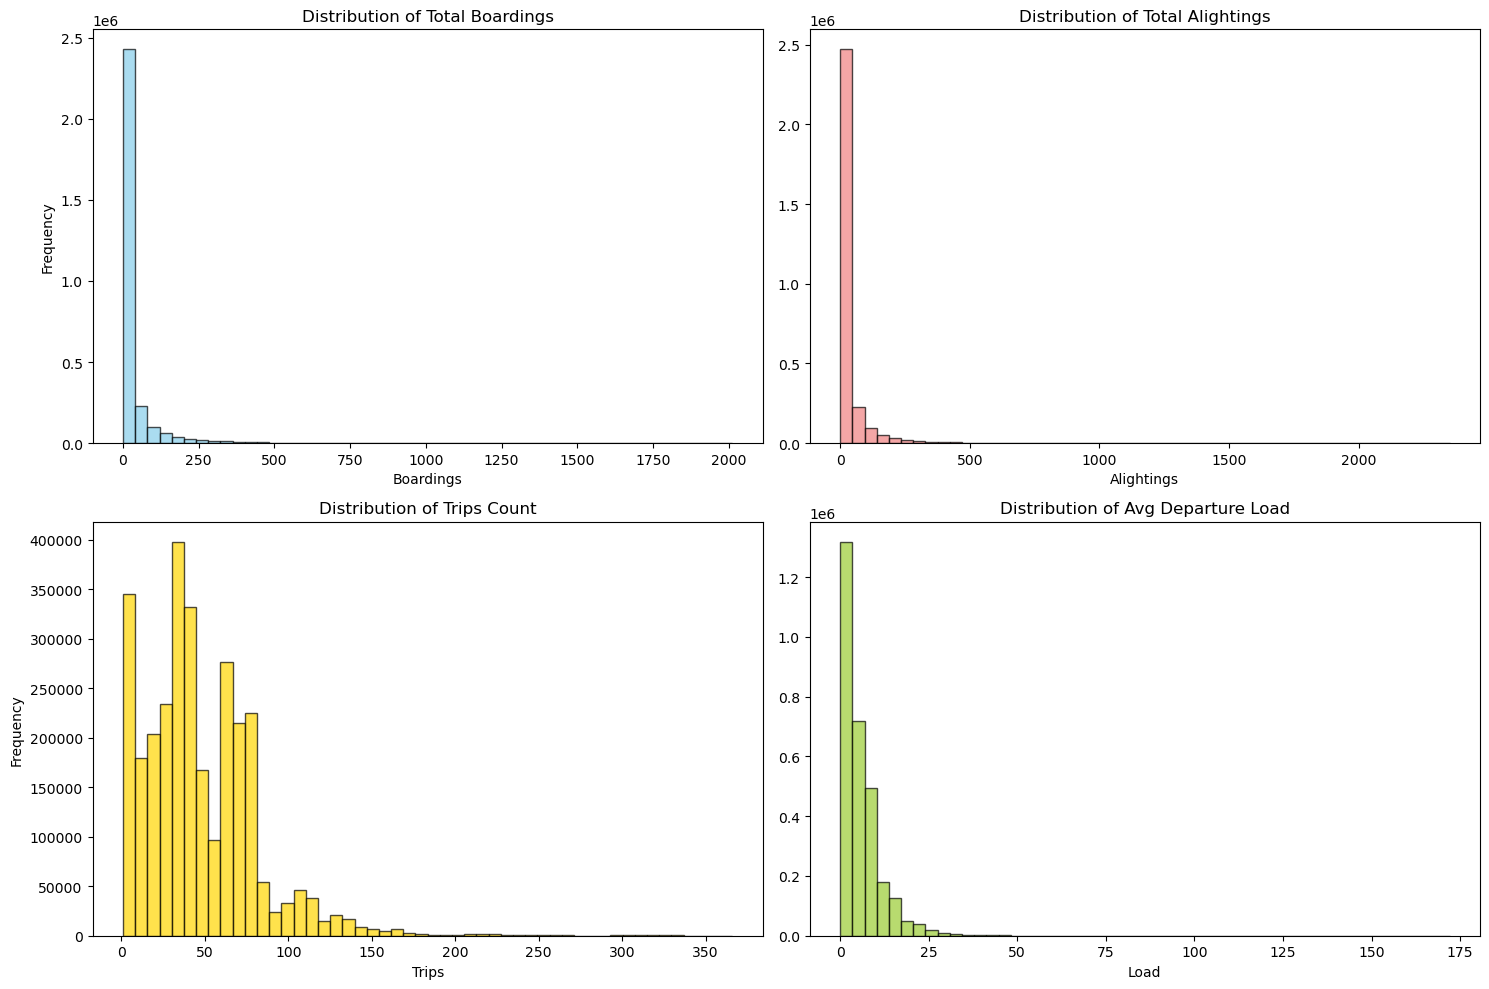

In [160]:
# Distribution of key ridership metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].hist(stop_clean['TOTAL_BOARDINGS'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].set_title('Distribution of Total Boardings')
axes[0,0].set_xlabel('Boardings')
axes[0,0].set_ylabel('Frequency')

axes[0,1].hist(stop_clean['TOTAL_ALIGHTINGS'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0,1].set_title('Distribution of Total Alightings')
axes[0,1].set_xlabel('Alightings')

axes[1,0].hist(stop_clean['TRIPS_COUNT'], bins=50, color='gold', edgecolor='black', alpha=0.7)
axes[1,0].set_title('Distribution of Trips Count')
axes[1,0].set_xlabel('Trips')
axes[1,0].set_ylabel('Frequency')

axes[1,1].hist(stop_clean['AVG_DEPARTURE_LOAD'], bins=50, color='yellowgreen', edgecolor='black', alpha=0.7)
axes[1,1].set_title('Distribution of Avg Departure Load')
axes[1,1].set_xlabel('Load')

plt.tight_layout()
plt.show()

## Time Based Analysis

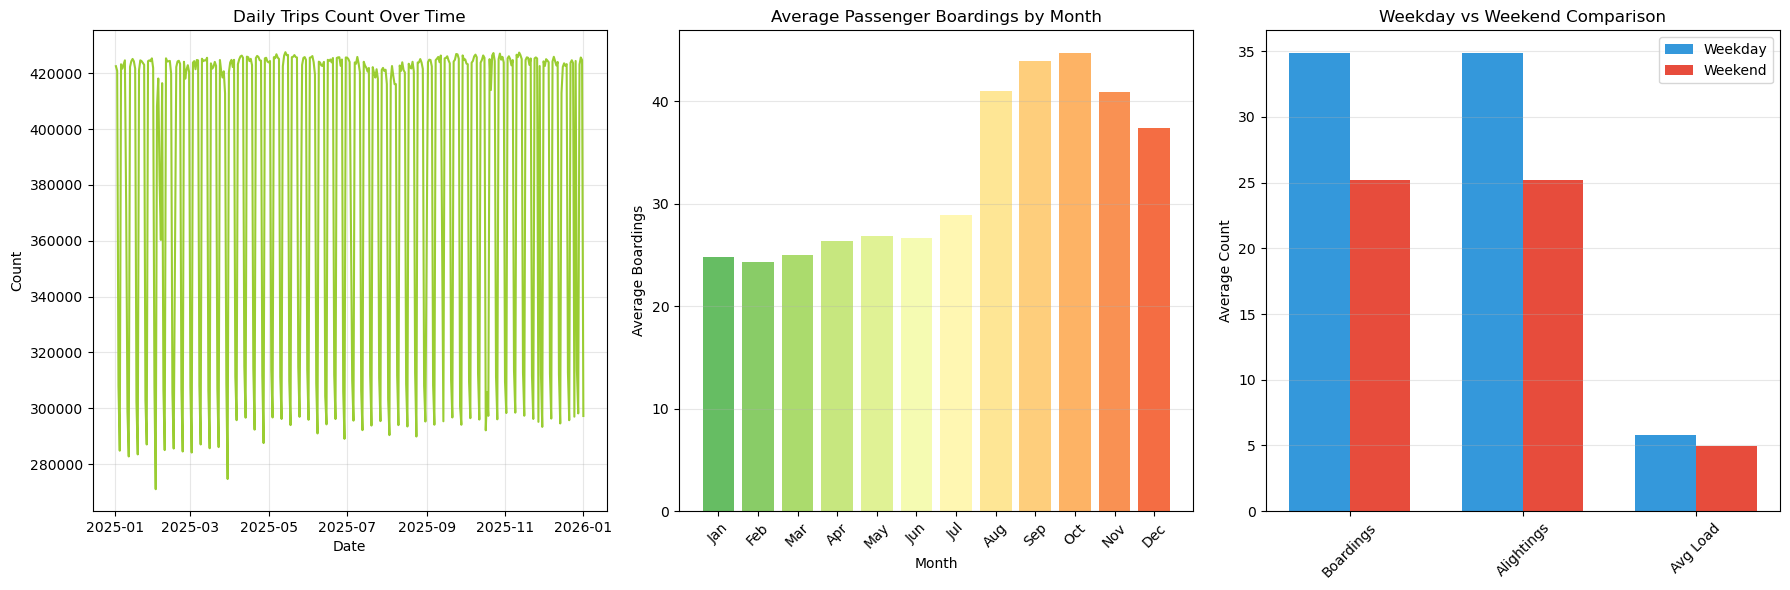

In [161]:
daily_stats = stop_clean.groupby('OPERATION_DATE').agg({
    'TOTAL_BOARDINGS': 'sum',
    'TOTAL_ALIGHTINGS': 'sum',
    'TRIPS_COUNT': 'sum'
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# number of trips over time
axes[0].plot(daily_stats['OPERATION_DATE'], daily_stats['TRIPS_COUNT'], color='yellowgreen')
axes[0].set_title('Daily Trips Count Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# average monthly boardings
monthly_boardings = stop_clean.groupby('MONTH')['TOTAL_BOARDINGS'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1].bar(range(len(monthly_boardings)), monthly_boardings.values, 
               color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(monthly_boardings))))
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Boardings')
axes[1].set_title('Average Passenger Boardings by Month')
axes[1].set_xticks(range(len(monthly_boardings)))
axes[1].set_xticklabels([month_names[i-1] for i in monthly_boardings.index], rotation=45)
axes[1].grid(alpha=0.3, axis='y')

# weekday vs weekend comparison
weekend_comparison = stop_clean.groupby('IS_WEEKEND')[['TOTAL_BOARDINGS', 'TOTAL_ALIGHTINGS', 'AVG_DEPARTURE_LOAD']].mean()
x = np.arange(len(weekend_comparison.columns))
axes[2].bar(x - width/2, weekend_comparison.iloc[0], width, label='Weekday', color='#3498db')
axes[2].bar(x + width/2, weekend_comparison.iloc[1], width, label='Weekend', color='#e74c3c')
axes[2].set_ylabel('Average Count')
axes[2].set_title('Weekday vs Weekend Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Boardings', 'Alightings', 'Avg Load'], rotation=15)
axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Ridership by Day of Week

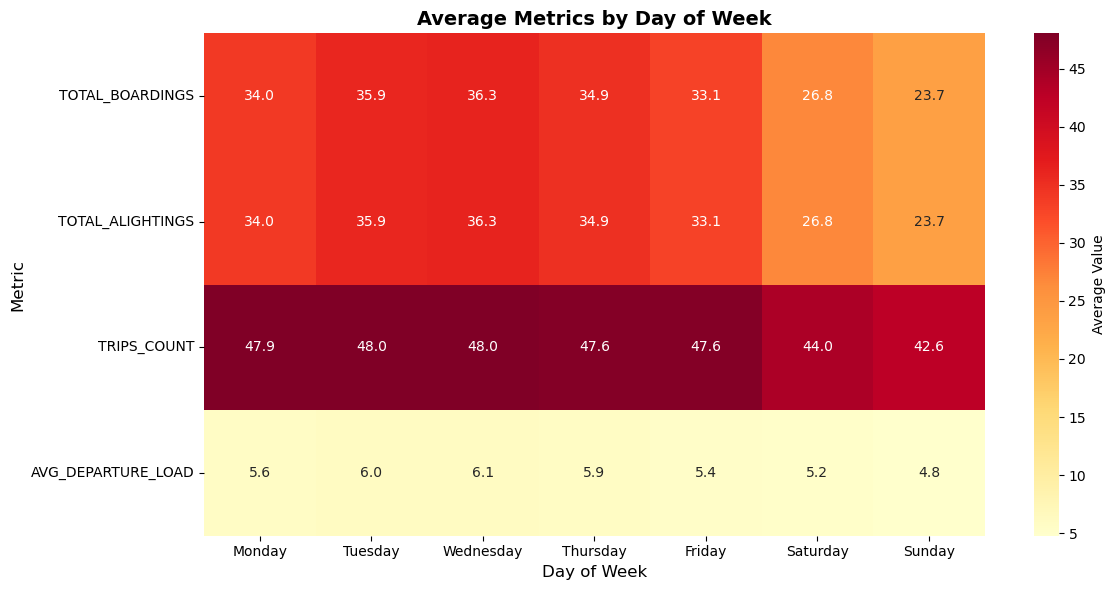

In [162]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_of_week_stats = stop_clean.groupby('DAY_NAME').agg({
    'TOTAL_BOARDINGS': 'mean',
    'TOTAL_ALIGHTINGS': 'mean',
    'TRIPS_COUNT': 'mean',
    'AVG_DEPARTURE_LOAD': 'mean'
}).reindex(day_order)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(day_of_week_stats.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Average Value'}, ax=ax)
ax.set_title('Average Metrics by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Metric', fontsize=12)

plt.tight_layout()
plt.show()

### Stop-level Analysis

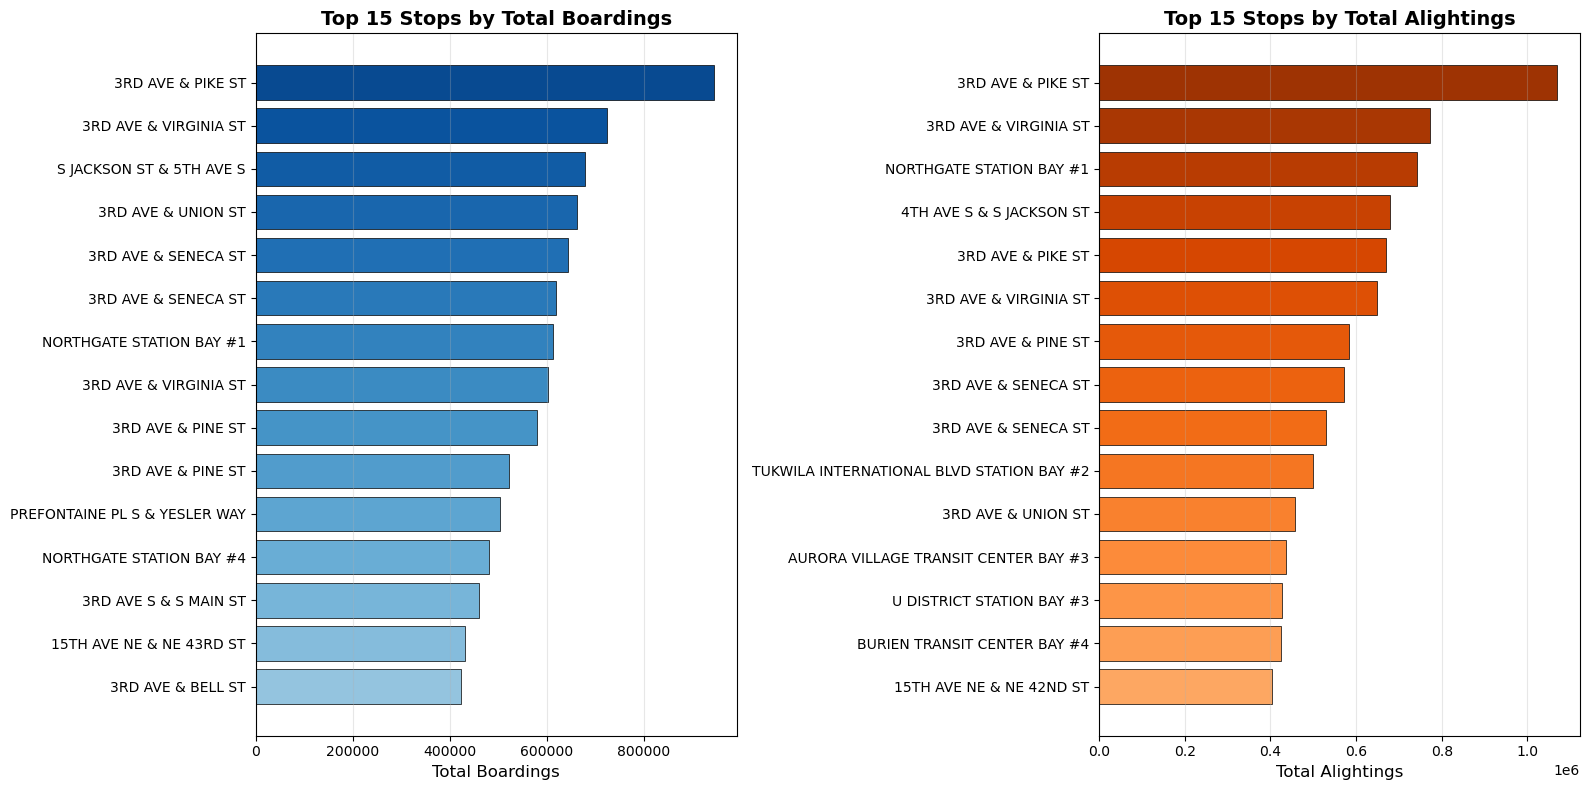

In [163]:
stop_summary = stop_clean.groupby(['STOP_ID', 'STOP_NM']).agg({
    'TOTAL_BOARDINGS': 'sum',
    'TOTAL_ALIGHTINGS': 'sum'
}).reset_index()

# Top 15 stops by total boardings
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_boardings = stop_summary.nlargest(15, 'TOTAL_BOARDINGS').sort_values('TOTAL_BOARDINGS')
colors_boardings = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_boardings)))
axes[0].barh(range(len(top_boardings)), top_boardings['TOTAL_BOARDINGS'], color=colors_boardings, edgecolor='black', linewidth=0.5)
axes[0].set_yticks(range(len(top_boardings)), top_boardings['STOP_NM'])
axes[0].set_xlabel('Total Boardings', fontsize=12)
axes[0].set_title('Top 15 Stops by Total Boardings', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# Top 15 stops by total alightings
top_alightings = stop_summary.nlargest(15, 'TOTAL_ALIGHTINGS').sort_values('TOTAL_ALIGHTINGS')
colors_alightings = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_alightings)))
axes[1].barh(range(len(top_alightings)), top_alightings['TOTAL_ALIGHTINGS'], 
             color=colors_alightings, edgecolor='black', linewidth=0.5)
axes[1].set_yticks(range(len(top_alightings)))
axes[1].set_yticklabels(top_alightings['STOP_NM'], fontsize=10)
axes[1].set_xlabel('Total Alightings', fontsize=12)
axes[1].set_title('Top 15 Stops by Total Alightings', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Route Analysis

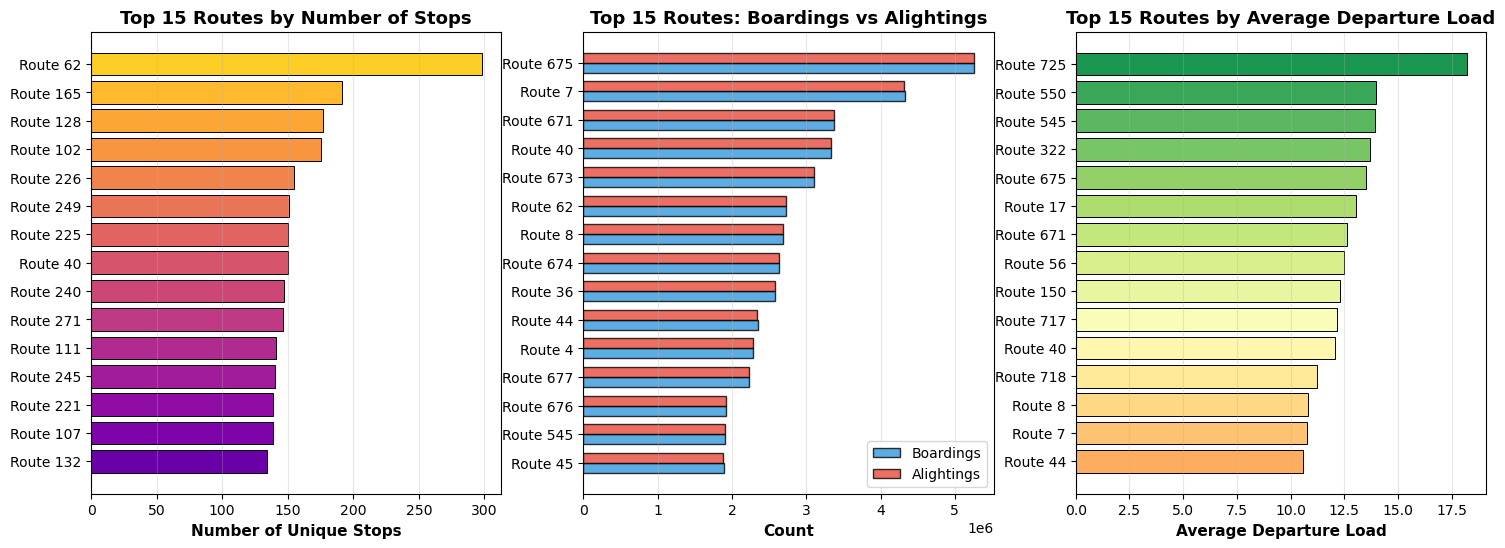

In [164]:
route_stats = stop_clean.groupby('SERVICE_RTE_LIST').agg({
    'TOTAL_BOARDINGS': 'sum',
    'TOTAL_ALIGHTINGS': 'sum',
    'STOP_ID': 'nunique',  # Number of unique stops
    'AVG_DEPARTURE_LOAD': 'mean'
}).reset_index()
route_stats.columns = ['ROUTE', 'TOTAL_BOARDINGS', 'TOTAL_ALIGHTINGS', 'UNIQUE_STOPS', 'AVG_LOAD']
route_stats['TOTAL_ACTIVITY'] = route_stats['TOTAL_BOARDINGS'] + route_stats['TOTAL_ALIGHTINGS']
route_stats = route_stats.sort_values('TOTAL_BOARDINGS', ascending=False)

#print("\nTop 10 Routes by Boardings:")
#print(route_stats.head(10))
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Top 15 Routes by Number of Stops
top_15_stops = route_stats.nlargest(15, 'UNIQUE_STOPS').sort_values('UNIQUE_STOPS')
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(top_15_stops)))

axes[0].barh(range(len(top_15_stops)), top_15_stops['UNIQUE_STOPS'], 
                color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_yticks(range(len(top_15_stops)))
axes[0].set_yticklabels([f"Route {int(r)}" for r in top_15_stops['ROUTE']], fontsize=10)
axes[0].set_xlabel('Number of Unique Stops', fontsize=11, fontweight='bold')
axes[0].set_title('Top 15 Routes by Number of Stops', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Top 15 Routes by Boardings vs Alightings
top_15_activity = route_stats.nlargest(15, 'TOTAL_ACTIVITY').sort_values('TOTAL_BOARDINGS')

x = np.arange(len(top_15_activity))
width = 0.35

bars1 = axes[1].barh(x - width/2, top_15_activity['TOTAL_BOARDINGS'], 
                        width, label='Boardings', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = axes[1].barh(x + width/2, top_15_activity['TOTAL_ALIGHTINGS'], 
                        width, label='Alightings', color='#e74c3c', alpha=0.8, edgecolor='black')

axes[1].set_yticks(x)
axes[1].set_yticklabels([f"Route {int(r)}" for r in top_15_activity['ROUTE']], fontsize=10)
axes[1].set_xlabel('Count', fontsize=11, fontweight='bold')
axes[1].set_title('Top 15 Routes: Boardings vs Alightings', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(axis='x', alpha=0.3)

# Top 15 Routes by Average Departure Load
top_15_load = route_stats.nlargest(15, 'AVG_LOAD').sort_values('AVG_LOAD')
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_15_load)))

axes[2].barh(range(len(top_15_load)), top_15_load['AVG_LOAD'], 
                color=colors, edgecolor='black', linewidth=0.7)
axes[2].set_yticks(range(len(top_15_load)))
axes[2].set_yticklabels([f"Route {int(r)}" for r in top_15_load['ROUTE']], fontsize=10)
axes[2].set_xlabel('Average Departure Load', fontsize=11, fontweight='bold')
axes[2].set_title('Top 15 Routes by Average Departure Load', fontsize=13, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

## Relationship Analysis

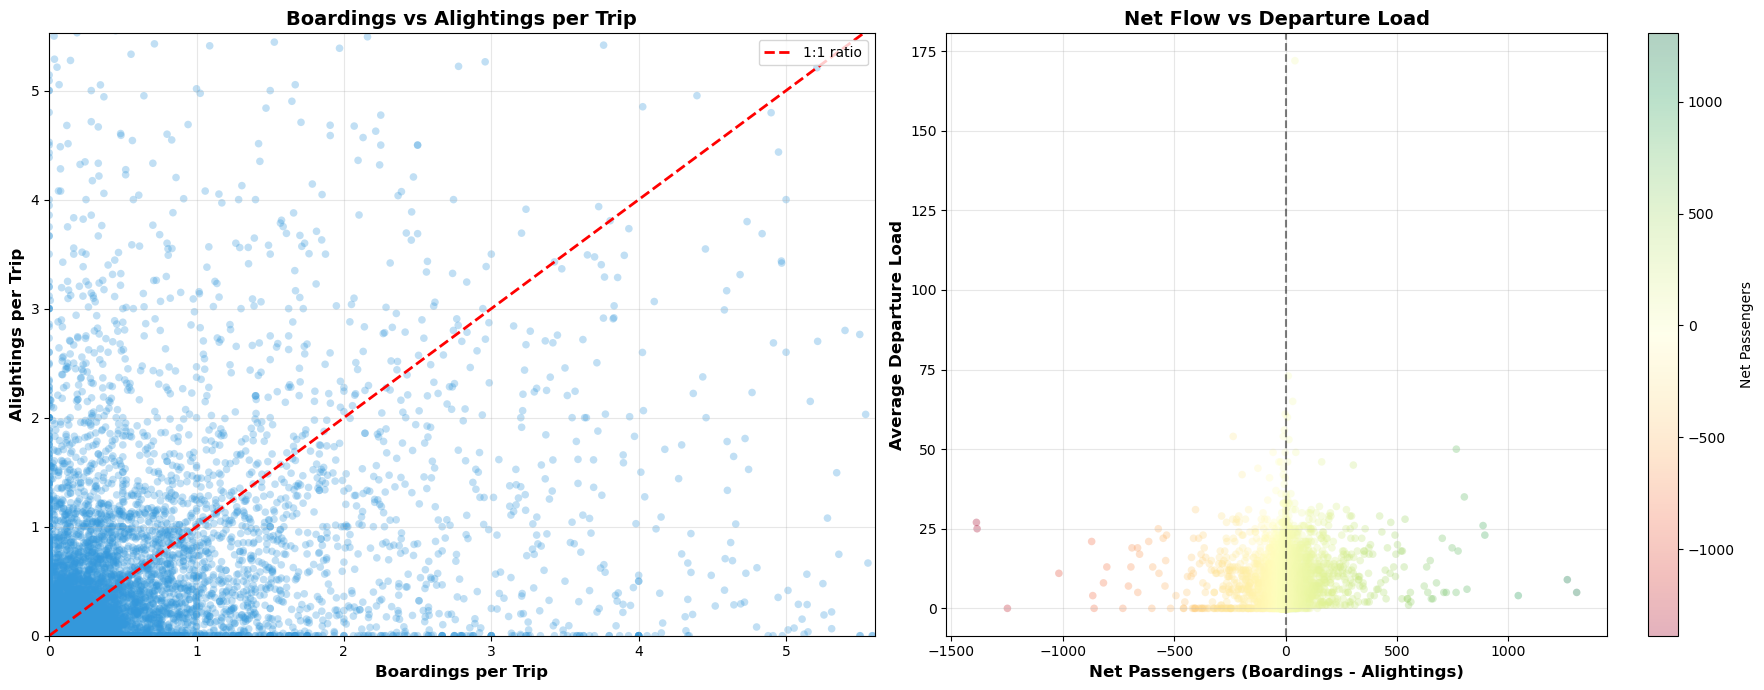

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Boardings per Trip vs Alightings per Trip
sample_data = stop_clean.sample(min(10000, len(stop_clean)))
axes[0].scatter(sample_data['BOARDINGS_PER_TRIP'], sample_data['ALIGHTINGS_PER_TRIP'],
                alpha=0.3, s=30, c='#3498db', edgecolors='none')
axes[0].plot([0, 20], [0, 20], 'r--', linewidth=2, label='1:1 ratio')
axes[0].set_xlabel('Boardings per Trip', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Alightings per Trip', fontsize=12, fontweight='bold')
axes[0].set_title('Boardings vs Alightings per Trip', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, min(20, stop_clean['BOARDINGS_PER_TRIP'].quantile(0.99)))
axes[0].set_ylim(0, min(20, stop_clean['ALIGHTINGS_PER_TRIP'].quantile(0.99)))

# Net Passengers vs Average Departure Load
axes[1].scatter(sample_data['NET_PASSENGERS'], sample_data['AVG_DEPARTURE_LOAD'],
                alpha=0.3, s=30, c=sample_data['NET_PASSENGERS'], 
                cmap='RdYlGn', edgecolors='none')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
axes[1].set_xlabel('Net Passengers (Boardings - Alightings)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Departure Load', fontsize=12, fontweight='bold')
axes[1].set_title('Net Flow vs Departure Load', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('Net Passengers', fontsize=10)

plt.tight_layout()
plt.show()


## Correlation Analysis

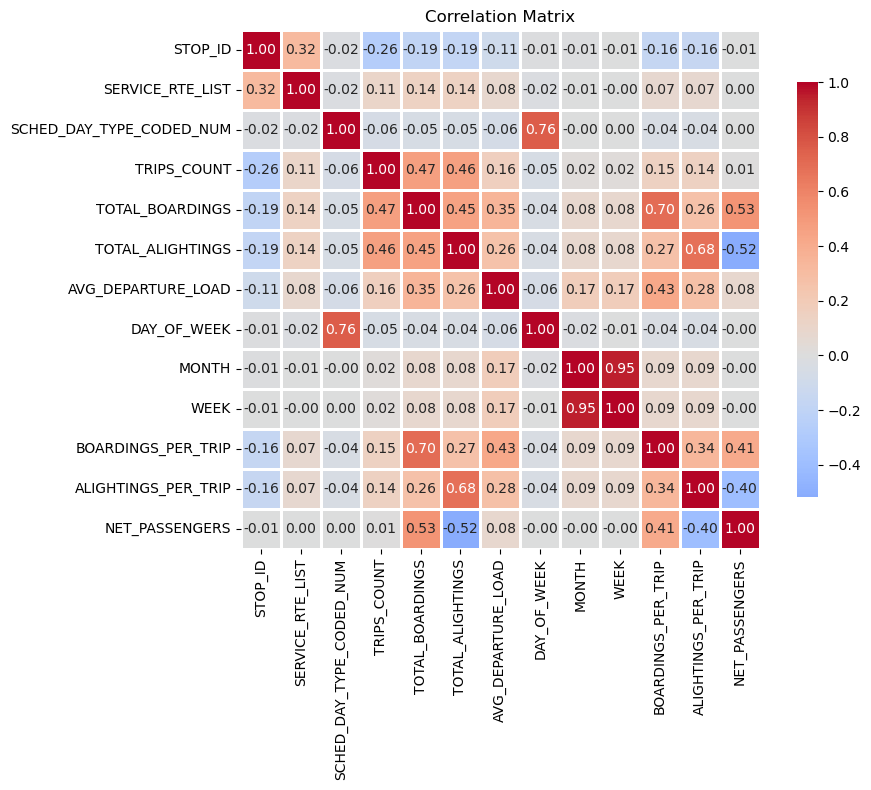

In [166]:
# Correlation matrix
numeric_cols = stop_clean.select_dtypes(include=[np.number]).columns.tolist()
corr = stop_clean[numeric_cols].corr()


plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


In [167]:
# Save the cleaned dataset
OUTPUT_FOLDER = '../datasets/cleaned/'
stop_clean.to_csv(OUTPUT_FOLDER + 'Stop_level_cleaned.csv', index=False)
print(f"\nCleaned stop data saved with {len(stop_clean)} rows")


Cleaned data saved with 2968575 rows
